
Station times:
2022: 2022-09-25 08:39
2023: 2023-09-23 23:25
2024: 2024-10-08 02:07

===== Deep offset correction =====
Reference layer: last 10 common points
Bottom/tail mean sigma0 (2022) = 27.210690
Bottom/tail mean sigma0 (2023) = 27.204005
Bottom/tail mean sigma0 (2024) = 27.196426
Offset applied to 2023 = 0.006685
Offset applied to 2024 = 0.014264

Around 400 m (380–420 m):
Depth (m)     sigma0_2022     sigma0_2023_raw  sigma0_2023_aln  sigma0_2024_raw  sigma0_2024_aln  diff23-22   diff24-23   diff24-22
  380.00      27.208254      27.202636      27.209320      27.194756      27.209020     0.001066    -0.000300     0.000766
  381.00      27.208271      27.202652      27.209337      27.194772      27.209037     0.001066    -0.000300     0.000766
  382.00      27.208287      27.202668      27.209353      27.194788      27.209053     0.001066    -0.000300     0.000766
  383.00      27.208303      27.202685      27.209369      27.194805      27.209069     0.001066    -0.000300     0

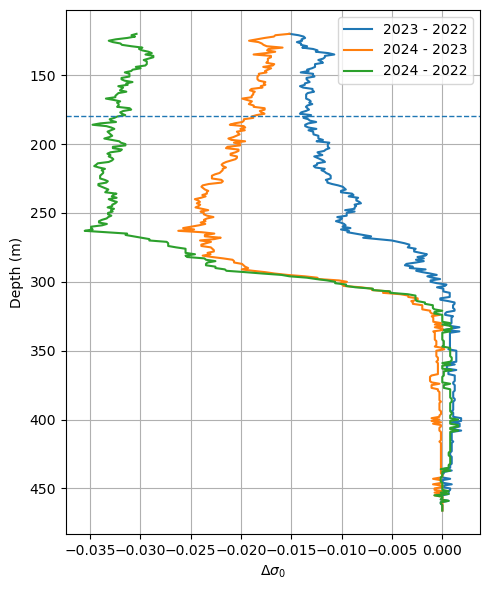

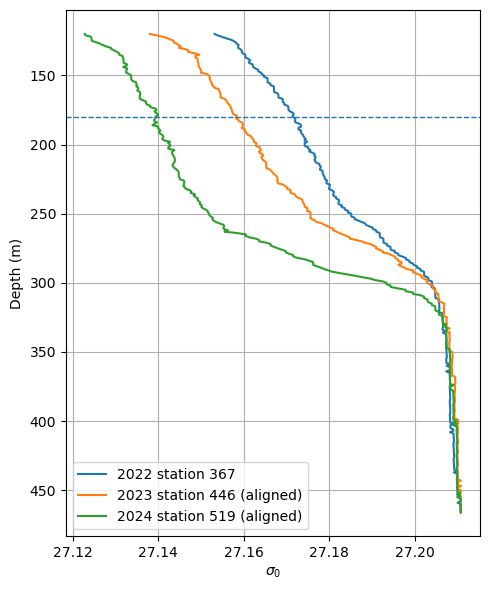

In [2]:
import GFPy.Ocean as Oc
import numpy as np
import gsw
import matplotlib.pyplot as plt
import pandas as pd

# =========================
# Read data
# =========================
# Original data (commented out, not deleted)
# file_2022 = r'C:\Users\quzho2904\OneDrive - University of Bergen\GEOF337\report\npy\KB2022602.npy'
# file_2024 = r'C:\Users\quzho2904\OneDrive - University of Bergen\GEOF337\report\npy\HB2024009007.npy'

# New data
file_2022 = r'C:\Users\quzho2904\OneDrive - University of Bergen\GEOF337\report\npy\GOS2022112.npy'
file_2023 = r'C:\Users\quzho2904\OneDrive - University of Bergen\GEOF337\report\npy\GOS2023001013.npy'
file_2024 = r'C:\Users\quzho2904\OneDrive - University of Bergen\GEOF337\report\npy\GOS2024001014.npy'

CTD_2022 = Oc.read_CTD(file_2022)
CTD_2023 = Oc.read_CTD(file_2023)
CTD_2024 = Oc.read_CTD(file_2024)

# =========================
# Unify LAT/LON field names
# =========================
for CTD in [CTD_2022, CTD_2023, CTD_2024]:
    for st in CTD.keys():
        if 'lat' in CTD[st]:
            CTD[st]['LAT'] = CTD[st]['lat']
        if 'lon' in CTD[st]:
            CTD[st]['LON'] = CTD[st]['lon']

# =========================
# Compute TEOS-10 sigma0
# =========================
def compute_sigma0(CTD):
    for st in CTD.keys():
        S = np.asarray(CTD[st]['S'], dtype=float)
        T = np.asarray(CTD[st]['T'], dtype=float)
        z = np.asarray(CTD[st]['P'], dtype=float)

        lon = float(CTD[st]['LON'])
        lat = float(CTD[st]['LAT'])

        # pressure in dbar
        p = z.copy()

        # make lengths consistent
        n = min(len(S), len(T), len(p))
        S = S[:n]
        T = T[:n]
        p = p[:n]

        valid = np.isfinite(S) & np.isfinite(T) & np.isfinite(p)
        S = S[valid]
        T = T[valid]
        p = p[valid]

        SA = gsw.SA_from_SP(S, p, lon, lat)
        CT = gsw.CT_from_t(SA, T, p)

        CTD[st]['P'] = p
        CTD[st]['S'] = S
        CTD[st]['T'] = T
        CTD[st]['SIGTH'] = gsw.sigma0(SA, CT)

compute_sigma0(CTD_2022)
compute_sigma0(CTD_2023)
compute_sigma0(CTD_2024)

# =========================
# Helper: get station safely
# =========================
def get_station_data(CTD, station_id):
    if station_id in CTD:
        return CTD[station_id]
    if str(station_id) in CTD:
        return CTD[str(station_id)]
    raise KeyError(f"Station {station_id} not found. Available keys example: {list(CTD.keys())[:10]}")

# =========================
# Helper: get station datetime safely
# =========================
def get_station_time(st):
    for key in ["datetime", "time", "TIME"]:
        if key in st:
            return str(st[key])
    return "unknown"

# =========================
# Select stations
# =========================
# Original station selection (commented out, not deleted)
# station_2022_id = 135
# station_2024_id = 15

station_2022_id = 367
station_2023_id = 446
station_2024_id = 519

st2022 = get_station_data(CTD_2022, station_2022_id)
st2023 = get_station_data(CTD_2023, station_2023_id)
st2024 = get_station_data(CTD_2024, station_2024_id)

time_2022 = get_station_time(st2022)
time_2023 = get_station_time(st2023)
time_2024 = get_station_time(st2024)

print("\nStation times:")
print("2022:", time_2022)
print("2023:", time_2023)
print("2024:", time_2024)

z1 = np.asarray(st2022['P'], dtype=float)
z2 = np.asarray(st2023['P'], dtype=float)
z3 = np.asarray(st2024['P'], dtype=float)

sig1 = np.asarray(st2022['SIGTH'], dtype=float)
sig2 = np.asarray(st2023['SIGTH'], dtype=float)
sig3 = np.asarray(st2024['SIGTH'], dtype=float)

# =========================
# Direct truncation to common length
# =========================
n = min(len(sig1), len(sig2), len(sig3), len(z1), len(z2), len(z3))

z_common = z1[:n]
sig1_common = sig1[:n]
sig2_common = sig2[:n]
sig3_common = sig3[:n]

# Raw differences
dsig_2023_minus_2022_raw = sig2_common - sig1_common
dsig_2024_minus_2023_raw = sig3_common - sig2_common
dsig_2024_minus_2022_raw = sig3_common - sig1_common

# =========================
# Deep alignment using last 10 points
# =========================
n_tail = 10  # Number of points from the bottom to use for alignment

if n < n_tail:
    raise ValueError(f"Not enough common points for tail alignment: n={n}, required={n_tail}")

tail_slice = slice(-n_tail, None)

bottom_mean_2022 = np.nanmean(sig1_common[tail_slice])
bottom_mean_2023 = np.nanmean(sig2_common[tail_slice])
bottom_mean_2024 = np.nanmean(sig3_common[tail_slice])

# Take 2022 as reference
offset_2023 = bottom_mean_2023 - bottom_mean_2022
offset_2024 = bottom_mean_2024 - bottom_mean_2022

# Align tail means to 2022
sig1_aligned = sig1_common.copy()
sig2_aligned = sig2_common - offset_2023
sig3_aligned = sig3_common - offset_2024

# Recompute differences after alignment
dsig_2023_minus_2022 = sig2_aligned - sig1_aligned
dsig_2024_minus_2023 = sig3_aligned - sig2_aligned
dsig_2024_minus_2022 = sig3_aligned - sig1_aligned

print("\n===== Deep offset correction =====")
print(f"Reference layer: last {n_tail} common points")
print(f"Bottom/tail mean sigma0 (2022) = {bottom_mean_2022:.6f}")
print(f"Bottom/tail mean sigma0 (2023) = {bottom_mean_2023:.6f}")
print(f"Bottom/tail mean sigma0 (2024) = {bottom_mean_2024:.6f}")
print(f"Offset applied to 2023 = {-offset_2023:.6f}")
print(f"Offset applied to 2024 = {-offset_2024:.6f}")

# =========================
# Print selected depth range
# =========================
mask = (z_common >= 380) & (z_common <= 420)

print('\nAround 400 m (380–420 m):')
print('Depth (m)     sigma0_2022     sigma0_2023_raw  sigma0_2023_aln  sigma0_2024_raw  sigma0_2024_aln  diff23-22   diff24-23   diff24-22')

for i in np.where(mask)[0]:
    print(
        f'{z_common[i]:8.2f}   '
        f'{sig1_aligned[i]:12.6f}   '
        f'{sig2_common[i]:12.6f}   '
        f'{sig2_aligned[i]:12.6f}   '
        f'{sig3_common[i]:12.6f}   '
        f'{sig3_aligned[i]:12.6f}   '
        f'{dsig_2023_minus_2022[i]:10.6f}   '
        f'{dsig_2024_minus_2023[i]:10.6f}   '
        f'{dsig_2024_minus_2022[i]:10.6f}'
    )

if np.any(mask):
    print('\nStatistics in this depth range after alignment:')
    print('mean diff (2023-2022) =', np.nanmean(dsig_2023_minus_2022[mask]))
    print('max diff  (2023-2022) =', np.nanmax(dsig_2023_minus_2022[mask]))
    print('min diff  (2023-2022) =', np.nanmin(dsig_2023_minus_2022[mask]))

    print('mean diff (2024-2023) =', np.nanmean(dsig_2024_minus_2023[mask]))
    print('max diff  (2024-2023) =', np.nanmax(dsig_2024_minus_2023[mask]))
    print('min diff  (2024-2023) =', np.nanmin(dsig_2024_minus_2023[mask]))

    print('mean diff (2024-2022) =', np.nanmean(dsig_2024_minus_2022[mask]))
    print('max diff  (2024-2022) =', np.nanmax(dsig_2024_minus_2022[mask]))
    print('min diff  (2024-2022) =', np.nanmin(dsig_2024_minus_2022[mask]))
else:
    print('\nNo data points found in 380–420 m.')

# =========================
# Save sigma0 data
# =========================
save_csv = r'C:\Users\quzho2904\OneDrive - University of Bergen\GEOF337\report\sigma0_station367_2022_vs_station446_2023_vs_station519_2024_aligned.csv'
save_npy = r'C:\Users\quzho2904\OneDrive - University of Bergen\GEOF337\report\sigma0_station367_2022_vs_station446_2023_vs_station519_2024_aligned.npy'

df_save = pd.DataFrame({
    'depth_m': z_common,
    'sigma0_2022_raw': sig1_common,
    'sigma0_2023_raw': sig2_common,
    'sigma0_2024_raw': sig3_common,
    'sigma0_2022_aligned': sig1_aligned,
    'sigma0_2023_aligned': sig2_aligned,
    'sigma0_2024_aligned': sig3_aligned,
    'sigma0_diff_2023_minus_2022_raw': dsig_2023_minus_2022_raw,
    'sigma0_diff_2024_minus_2023_raw': dsig_2024_minus_2023_raw,
    'sigma0_diff_2024_minus_2022_raw': dsig_2024_minus_2022_raw,
    'sigma0_diff_2023_minus_2022': dsig_2023_minus_2022,
    'sigma0_diff_2024_minus_2023': dsig_2024_minus_2023,
    'sigma0_diff_2024_minus_2022': dsig_2024_minus_2022,
    'datetime_2022': time_2022,
    'datetime_2023': time_2023,
    'datetime_2024': time_2024
})

df_save.to_csv(save_csv, index=False, encoding='utf-8-sig')

save_dict = {
    'depth_m': z_common,
    'sigma0_2022_raw': sig1_common,
    'sigma0_2023_raw': sig2_common,
    'sigma0_2024_raw': sig3_common,
    'sigma0_2022_aligned': sig1_aligned,
    'sigma0_2023_aligned': sig2_aligned,
    'sigma0_2024_aligned': sig3_aligned,
    'sigma0_diff_2023_minus_2022_raw': dsig_2023_minus_2022_raw,
    'sigma0_diff_2024_minus_2023_raw': dsig_2024_minus_2023_raw,
    'sigma0_diff_2024_minus_2022_raw': dsig_2024_minus_2022_raw,
    'sigma0_diff_2023_minus_2022': dsig_2023_minus_2022,
    'sigma0_diff_2024_minus_2023': dsig_2024_minus_2023,
    'sigma0_diff_2024_minus_2022': dsig_2024_minus_2022,
    'tail_n_points': n_tail,
    'tail_mean_2022': bottom_mean_2022,
    'tail_mean_2023': bottom_mean_2023,
    'tail_mean_2024': bottom_mean_2024,
    'offset_2023_relative_to_2022': offset_2023,
    'offset_2024_relative_to_2022': offset_2024,
    'station_2022_id': station_2022_id,
    'station_2023_id': station_2023_id,
    'station_2024_id': station_2024_id,
    'datetime': {
        '2022': time_2022,
        '2023': time_2023,
        '2024': time_2024
    }
}

np.save(save_npy, save_dict)

print(f'\nSaved csv to:\n{save_csv}')
print(f'Saved npy to:\n{save_npy}')

# =========================
# Plot sigma0 difference profiles
# =========================
mask_deep = z_common >= 120

plt.figure(figsize=(5, 6))

plt.plot(dsig_2023_minus_2022[mask_deep], z_common[mask_deep], label='2023 - 2022')
plt.plot(dsig_2024_minus_2023[mask_deep], z_common[mask_deep], label='2024 - 2023')
plt.plot(dsig_2024_minus_2022[mask_deep], z_common[mask_deep], label='2024 - 2022')

plt.axhline(180, linestyle='--', linewidth=1)

plt.gca().invert_yaxis()
plt.xlabel(r'$\Delta \sigma_0$')
plt.ylabel('Depth (m)')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# =========================
# Plot aligned sigma0 profiles
# =========================
plt.figure(figsize=(5, 6))

plt.plot(sig1_aligned[mask_deep], z_common[mask_deep], label=f'2022 station {station_2022_id}')
plt.plot(sig2_aligned[mask_deep], z_common[mask_deep], label=f'2023 station {station_2023_id} (aligned)')
plt.plot(sig3_aligned[mask_deep], z_common[mask_deep], label=f'2024 station {station_2024_id} (aligned)')

plt.axhline(180, linestyle='--', linewidth=1)

plt.gca().invert_yaxis()
plt.xlabel(r'$\sigma_0$')
plt.ylabel('Depth (m)')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()